# Определение возраста покупателей

# Описание проекта

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
* Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
* Контролировать добросовестность кассиров при продаже алкоголя.<br>

Построим модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

# Описание данных

Данные взяты с сайта ChaLearn Looking at People. Они находятся в папке **`/datasets/faces/.`**

В нашем распоряжении одна папка со всеми изображениями **`(/final_files) и CSV-файл labels.csv`** с двумя колонками:
* **file_name** - наименование файла
* **real_age** - реальный возраст челова на фото

# План исследования

* Загрузка и изучение данных
* Исследовательский анализ данных
* Подготовка данных к обучению
* Обученим нейронную сеть и рассчитайем её качество
* Общий вывод

## Исследовательский анализ данных

In [13]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

In [14]:
def load_train(path):
    
    df = pd.read_csv(f'{path}/labels.csv')
    datagen = ImageDataGenerator(rescale=1./255)
    
    train_data = datagen.flow_from_dataframe(
        dataframe = df,
        directory = f'{path}/final_files',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)
      
    
    return train_data

In [3]:
train_gen = load_train('/datasets/faces/')
all_targets = np.concatenate([train_gen[i][1] for i in range(len(train_gen))])
all_targets.shape

Found 7591 validated image filenames.


(7591,)

In [4]:
df_ages = pd.DataFrame(all_targets, columns=['real_age'])

In [5]:
df_ages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   real_age  7591 non-null   int64
dtypes: int64(1)
memory usage: 59.4 KB


In [6]:
df_ages.head()

,real_age
0,50
1,41
2,46
3,85
4,14


In [7]:
df_ages.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


In [8]:
df_ages.isnull().sum()

real_age    0
dtype: int64

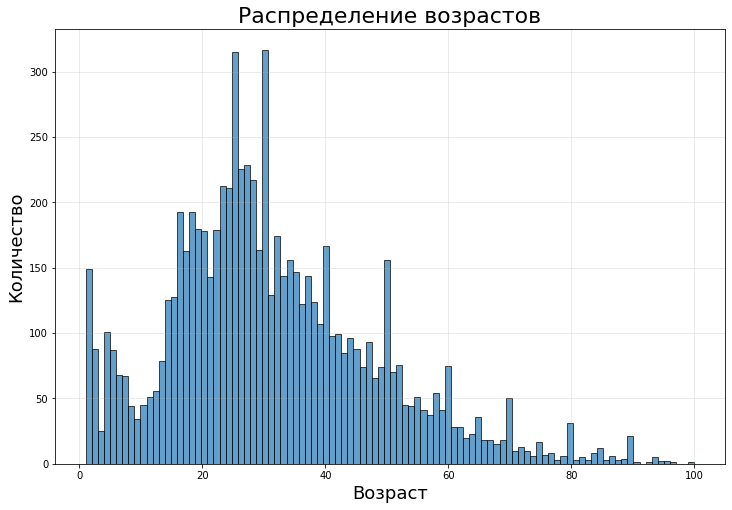

In [10]:
plt.figure(figsize=(12, 8))
plt.hist(all_targets, bins=100, edgecolor='black', alpha=0.7)
plt.title('Распределение возрастов', fontsize=22)
plt.xlabel('Возраст', fontsize=18)
plt.ylabel('Количество', fontsize=18)
plt.grid(True, alpha=0.3)
plt.show()

Found 7591 validated image filenames.


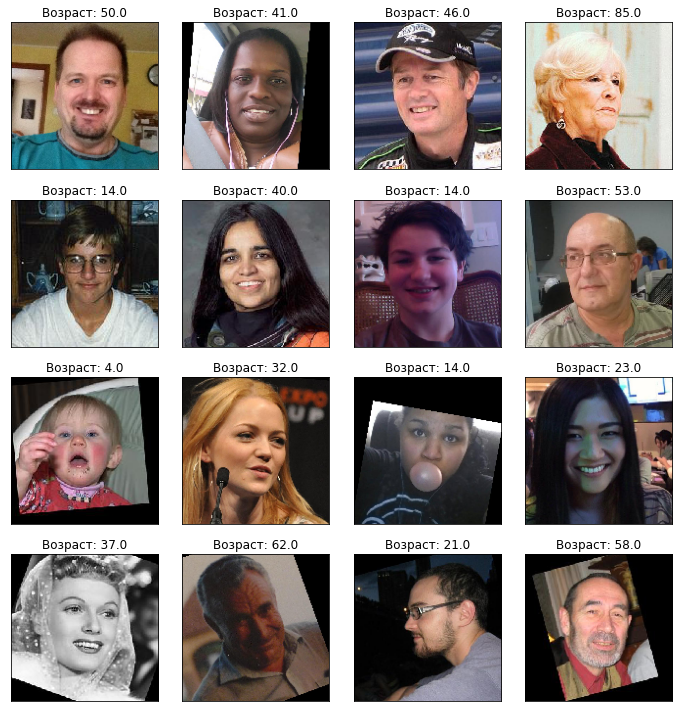

In [12]:
features, target = next(load_train('/datasets/faces/'))

fig = plt.figure(figsize=(10,10))
for i in range(16):
    fig.add_subplot(4, 4, i+1)
    plt.imshow(features[i])
    plt.title(f'Возраст: {target[i]:.1f}', fontsize=12)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

### Промежуточный вывод

1. Размер нашей выборки фотографий с именами и реальным возрастом составляет 7591, что в мировом масштабе является относительно не большим количеством, возможно этого будет достаточно для решения конкретно нашей задачи определения возраста
2. Судя по распределению нашей выборки по возрастам львиную долю составляют молодые люди с возрастом 25-35 лет. Возраст людей на фото примерно совпадает с реальным возрастом. Соответственно модель будет лучше определять данную возрастную группу, так как она больше представлена.
3. На фото присутствуют возраста от 1 года до 100 лет. Медианое значение находится на уровне 29 лет, что не сильно отличается от среденего - 31 год.
4. В выборке обнаружена аномально высокая частотность возрастов, кратных 10, что может говорить о наличии систематической ошибки в данных, так как в реальности не должно быть такого четкого разделения. Это важно учитывать при интерпретации качества модели: высокая точность предсказания в таких условиях может означать, что модель просто научилась хорошо угадывать округленные значения, а не реальный возраст.

## Обучение модели

Перенесем сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-модуле, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

def load_train(path):
    
    df = pd.read_csv(f'{path}/labels.csv')
    
    df_train_val, df_test = train_test_split(
        df, 
        test_size=0.2,
        random_state=12345
    )
    
    global test_indices
    test_indices = df_test.index
    
    datagen = ImageDataGenerator(rotation_range=3, horizontal_flip=True, height_shift_range=0.05,
        width_shift_range=0.05, validation_split=0.25, rescale=1./255)
    
    train_data = datagen.flow_from_dataframe(
        dataframe=df_train_val,
        directory = f'{path}/final_files',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)
    
    validation_data = datagen.flow_from_dataframe(
        dataframe = df_train_val,
        directory = f'{path}/final_files',
        x_col = 'file_name',
        y_col = 'real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)
    
    
    return train_data, validation_data

def load_test(path):
    
    df = pd.read_csv(f'{path}/labels.csv')
    df_test = df.loc[test_indices]
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    test_data = test_datagen.flow_from_dataframe(
        dataframe = df_test,
        directory = f'{path}/final_files',
        x_col = 'file_name',
        y_col = 'real_age', 
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        shuffle=False,
        seed=12345)
    
    
    return test_data

def create_model(input_shape=(224, 224, 3), learning_rate=0.0001):
    
    backbone = ResNet50(input_shape=input_shape,
                    weights='imagenet', 
                    include_top=False)
    
    #backbone.trainable = False
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    
    model.add(Dropout(0.3))
    
    model.add(Dense(1))  
   
    optimizer = Adam(learning_rate=learning_rate)  
    model.compile(optimizer=optimizer, loss='mean_absolute_error',
                  metrics=['mae'])
    
    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=20,
               steps_per_epoch=None, validation_steps=None):
    
    if isinstance(train_data, tuple) and len(train_data) == 2:
        train_data, test_data = train_data
    
    early_stop = EarlyStopping(
        monitor='val_mae',
        patience=3,
        restore_best_weights=True,
        mode='min'
    )
    
    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        batch_size=batch_size,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=[early_stop],
        verbose=2
    )

    return model 

```

```

Train for 285 steps, validate for 95 steps
Epoch 1/20
2026-03-08 18:01:19.609261: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2026-03-08 18:01:19.905272: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
285/285 - 93s - loss: 11.1952 - mae: 11.1972 - val_loss: 27.6341 - val_mae: 27.6327
Epoch 2/20
285/285 - 86s - loss: 8.0018 - mae: 8.0026 - val_loss: 15.0207 - val_mae: 15.0202
Epoch 3/20
285/285 - 86s - loss: 7.2958 - mae: 7.2986 - val_loss: 10.9102 - val_mae: 10.9127
Epoch 4/20
285/285 - 86s - loss: 6.7776 - mae: 6.7807 - val_loss: 9.6200 - val_mae: 9.6219
Epoch 5/20
285/285 - 86s - loss: 6.1670 - mae: 6.1688 - val_loss: 9.6446 - val_mae: 9.6464
Epoch 6/20
285/285 - 86s - loss: 5.8579 - mae: 5.8595 - val_loss: 7.3506 - val_mae: 7.3547
Epoch 7/20
285/285 - 86s - loss: 5.4583 - mae: 5.4607 - val_loss: 7.8762 - val_mae: 7.8781
Epoch 8/20
285/285 - 86s - loss: 5.2386 - mae: 5.2419 - val_loss: 7.1733 - val_mae: 7.1764
Epoch 9/20
285/285 - 86s - loss: 4.8253 - mae: 4.8259 - val_loss: 6.9615 - val_mae: 6.9656
Epoch 10/20
285/285 - 88s - loss: 4.6842 - mae: 4.6842 - val_loss: 6.7777 - val_mae: 6.7812
Epoch 11/20
285/285 - 86s - loss: 4.4734 - mae: 4.4746 - val_loss: 6.9124 - val_mae: 6.9151
Epoch 12/20
285/285 - 87s - loss: 4.2153 - mae: 4.2127 - val_loss: 7.5031 - val_mae: 7.5067
Epoch 13/20
285/285 - 86s - loss: 4.1497 - mae: 4.1487 - val_loss: 7.4019 - val_mae: 7.4042
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
95/95 - 8s - loss: 6.7460 - mae: 6.7456
Test MAE: 6.7456

```

## Анализ обученной модели

* Качество обучения
    * Модель достигла MAE = 6.75 лет на тестовой выборке
    * Лучший результат валидации: 6.78 (эпоха 10)
    * Улучшение с 7.33 до 6.75 после увеличения разрешения до 224x224
    
* Сходимость
    * Быстрая сходимость в первые 5 эпох (27.6 → 9.6)
    * Стабилизация после 6-й эпохи
    * Early stopping сработал на 13-й эпохе (patience=3)
    
* Обобщающая способность
    * Нет переобучения: тест (6.75) ≈ валидация (6.78)
    * Модель хорошо обобщает на новые данные

* Архитектура
    * ResNet50 + GlobalAveragePooling2D + Dropout(0.3) показала эффективность
    * Размер батча 16 оптимален
    * Learning rate 0.0001 подобран верно
    
**Практическая значимость**
* В контексте решения нашей задачи точность модели по определению возраста составляет +-7лет с учетом возможного отклонения от реального, что является приемлемым для среднего и старшего возрастов. Однако, для платежспособной группы людей от 18-25 лет ошибка все же существенная - интересы по покупкам в этом возрасте могут сильно отличаться в возрастной группе 18 и возрастной группе 25 лет. Поэтому, модель нужно дорабатывать в дальнейшем. Этого же касается запрос на продажу алкоголя. При разнице в 7 лет алгоритм может ошибочно 'позволить' продать алкоголь 14-15 летним подросткам, приняв их за 20-22 летних